# Model

In [3]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBRegressor

from src import config as c, data, model

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.figsize": (10, 3), "axes.grid": True, "grid.alpha": .3})

## Dataset

In [4]:
us = data.dataset("us")
china = data.dataset("china")

In [5]:
us.shape, china.shape

((288, 12), (264, 11))

In [6]:
us.tail(3)

,d1_lpg,d2_naphtha,d3_gasoline,d4_jetkero,d5_gasoil,d6_fueloil,d7_other,inc,ind,rpk,vmt,rpo_real
month,,,,,,,,,,,,
2025-10-01,"1,100.97",138.97,"9,055.35","1,713.52","4,420.90",338.48,"4,262.10","18,094.60",101.67,"110,272,196.00","297,161.00",0.21
2025-11-01,"1,159.70",149.47,"8,720.57","1,706.30","4,069.50",392.63,"4,171.50","18,037.30",101.22,"103,883,418.00","295,928.00",0.21
2025-12-01,"1,466.87",168.26,"8,814.55","1,766.58","4,091.10",414.39,"4,263.71","18,035.10",101.03,"89,828,167.00","279,611.00",0.20


## Forecast setup

In [7]:
origin = pd.Timestamp(c.ORIGIN)  # the forecast is made with what was published by the end of this month
origin

Timestamp('2023-12-01 00:00:00')

In [8]:
model.HORIZON

12

In [9]:
list(model.LAGS)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

In [10]:
pd.date_range(origin + pd.DateOffset(months=1), periods=model.HORIZON, freq="MS")  # target months t+1 ... t+12

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[us]', freq='MS')

In [11]:
c.EXCLUDE_YEARS

[2020]

## Features

In [12]:
X, y = model.features(us, "d3_gasoline", step=12)

In [13]:
X.columns

Index(['lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10',
       'lag11', 'lag12', 'lag13', 'inc', 'ind', 'rpk', 'vmt', 'rpo_real'],
      dtype='str')

In [14]:
X.loc[[origin]].T  # the information set at the origin

month,2023-12-01
lag2,"9,133.10"
lag3,"8,862.10"
lag4,"9,336.65"
lag5,"9,050.42"
lag6,"9,315.77"
lag7,"9,141.35"
lag8,"9,028.23"
lag9,"9,042.26"
lag10,"8,747.79"
lag11,"8,311.52"


In [15]:
y.loc[origin], origin + pd.DateOffset(months=12)  # the target: gasoline twelve months later

(np.float64(8824.3226), Timestamp('2024-12-01 00:00:00'))

In [16]:
# what each driver at the origin describes, and when it was published
month_end = origin + pd.offsets.MonthEnd(0)
described = {name: s.loc[:month_end - pd.offsets.MonthEnd(c.LAG[name])].index[-1]
             for name, s in data.predictors("us").items()}
pd.DataFrame({"period_end": described,
              "available_at": {name: end + pd.offsets.MonthEnd(c.LAG[name]) for name, end in described.items()},
              "value": X.loc[origin, list(described)]})

,period_end,available_at,value
inc,2023-11-30,2023-12-31,"17,427.10"
ind,2023-11-30,2023-12-31,100.86
rpk,2023-09-30,2023-12-31,"88,395,156.00"
vmt,2023-09-30,2023-12-31,"273,125.00"
rpo_real,2023-11-30,2023-12-31,0.27


In [17]:
rows = model.trainable(X, y, step=12, origin=origin)
rows.sum()

np.int64(226)

In [18]:
X.index[rows].max(), X.index[rows].max() + pd.DateOffset(months=12)  # last training origin, its target

(Timestamp('2022-10-01 00:00:00'), Timestamp('2023-10-01 00:00:00'))

In [19]:
X.index[rows].year.value_counts().sort_index()

month
2002    12
2003    12
2004    12
2005    12
2006    12
2007    12
2008    12
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2021    12
2022    10
Name: count, dtype: int64

In [20]:
# scaling changes nothing for a tree: same rows, raw against standardised
scaled = (X - X[rows].mean()) / X[rows].std()
raw_fit = XGBRegressor(**model.PARAMS).fit(X[rows], y[rows]).predict(X.loc[[origin]])
scaled_fit = XGBRegressor(**model.PARAMS).fit(scaled[rows], y[rows]).predict(scaled.loc[[origin]])
raw_fit, scaled_fit

(array([9010.122], dtype=float32), array([9010.122], dtype=float32))

## Validation

In [21]:
fit_X, fit_y = X[rows], y[rows]
block = len(fit_X) // 4
for k in (1, 2, 3):
    cut = block * k
    print(f"fold {k}   train {fit_X.index[0]:%Y-%m} to {fit_X.index[cut - 12 - 1]:%Y-%m}"
          f"   validate {fit_X.index[cut]:%Y-%m} to {fit_X.index[cut + block - 1]:%Y-%m}")

fold 1   train 2002-01 to 2005-08   validate 2006-09 to 2011-04
fold 2   train 2002-01 to 2010-04   validate 2011-05 to 2015-12
fold 3   train 2002-01 to 2014-12   validate 2016-01 to 2022-08


In [22]:
params = {"learning_rate": 0.03, "max_depth": 3, "n_estimators": 600}
model.cv_score(fit_X, fit_y, step=12, params=params)

np.float64(117161.29445390635)

## Hyperparameters

In [23]:
model.GRID

[{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200},
 {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 600},
 {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200},
 {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 600},
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200},
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 600},
 {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200},
 {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 600}]

In [24]:
cv = pd.DataFrame(model.GRID)
cv["mse"] = [model.cv_score(fit_X, fit_y, 12, p) for p in model.GRID]
cv.sort_values("mse")

,learning_rate,max_depth,n_estimators,mse
2,0.03,5,200,"112,002.93"
3,0.03,5,600,"113,587.67"
0,0.03,3,200,"115,027.32"
7,0.10,5,600,"115,237.84"
6,0.10,5,200,"115,254.83"
4,0.10,3,200,"116,875.59"
5,0.10,3,600,"117,125.94"
1,0.03,3,600,"117,161.29"


## Forecast

In [25]:
%%time
path_us, chosen_us = model.forecast(us)
path_china, chosen_china = model.forecast(china)

CPU times: user 1min 16s, sys: 55 s, total: 2min 11s
Wall time: 1min 28s


In [26]:
pd.DataFrame(chosen_us).T

,learning_rate,max_depth,n_estimators
d1_lpg,0.10,5.00,200.00
d2_naphtha,0.10,5.00,200.00
d3_gasoline,0.03,5.00,200.00
d4_jetkero,0.03,5.00,200.00
d5_gasoil,0.03,5.00,200.00
d6_fueloil,0.03,3.00,600.00
d7_other,0.10,3.00,200.00


In [27]:
path_us.round(0)

,d1_lpg,d2_naphtha,d3_gasoline,d4_jetkero,d5_gasoil,d6_fueloil,d7_other
2024-01-01,"1,376.00",148.00,"8,733.00","1,662.00","4,245.00",296.00,"3,623.00"
2024-02-01,"1,199.00",133.00,"8,979.00","1,679.00","4,289.00",349.00,"3,734.00"
2024-03-01,"1,055.00",140.00,"9,111.00","1,690.00","4,279.00",352.00,"3,818.00"
2024-04-01,"1,051.00",138.00,"9,153.00","1,718.00","4,226.00",336.00,"3,960.00"
2024-05-01,846.00,154.00,"9,278.00","1,751.00","4,269.00",290.00,"4,080.00"
2024-06-01,883.00,136.00,"9,272.00","1,791.00","4,214.00",283.00,"4,193.00"
2024-07-01,908.00,146.00,"9,218.00","1,837.00","4,022.00",338.00,"4,112.00"
2024-08-01,958.00,130.00,"9,300.00","1,776.00","4,301.00",382.00,"4,054.00"
2024-09-01,"1,112.00",146.00,"9,063.00","1,759.00","4,214.00",325.00,"3,956.00"
2024-10-01,"1,142.00",141.00,"9,161.00","1,761.00","4,286.00",365.00,"3,920.00"


In [28]:
path_china.round(0)

,d1_lpg,d2_naphtha,d3_gasoline,d4_jetkero,d5_gasoil,d6_fueloil,d7_other
2024-01-01,"2,656.00","2,185.00","3,079.00",775.00,"4,046.00",990.00,"2,371.00"
2024-02-01,"2,505.00","2,186.00","3,095.00",749.00,"4,050.00","1,014.00","1,585.00"
2024-03-01,"2,409.00","2,192.00","3,024.00",725.00,"4,145.00","1,002.00","2,335.00"
2024-04-01,"2,441.00","2,211.00","3,025.00",672.00,"4,027.00","1,028.00","2,713.00"
2024-05-01,"2,740.00","2,221.00","3,094.00",688.00,"3,935.00","1,052.00","1,857.00"
2024-06-01,"2,688.00","2,192.00","2,993.00",589.00,"3,937.00","1,063.00","2,756.00"
2024-07-01,"2,728.00","2,238.00","2,765.00",429.00,"3,953.00","1,098.00","2,342.00"
2024-08-01,"2,747.00","2,137.00","3,064.00",506.00,"4,002.00","1,043.00","1,984.00"
2024-09-01,"2,783.00","2,231.00","3,121.00",584.00,"3,937.00","1,041.00","2,190.00"
2024-10-01,"2,667.00","2,187.00","3,373.00",701.00,"3,972.00","1,060.00","1,253.00"


## Baseline

In [29]:
naive_us = model.seasonal_naive(us)
naive_china = model.seasonal_naive(china)
naive_us.round(0)

,d1_lpg,d2_naphtha,d3_gasoline,d4_jetkero,d5_gasoil,d6_fueloil,d7_other
2024-01-01,"1,311.00",142.00,"8,312.00","1,561.00","4,138.00",311.00,"3,493.00"
2024-02-01,"1,142.00",112.00,"8,748.00","1,553.00","4,255.00",396.00,"3,668.00"
2024-03-01,"1,030.00",144.00,"9,042.00","1,623.00","4,368.00",279.00,"3,712.00"
2024-04-01,911.00,156.00,"9,028.00","1,639.00","4,162.00",207.00,"4,050.00"
2024-05-01,810.00,157.00,"9,141.00","1,701.00","4,268.00",254.00,"4,179.00"
2024-06-01,945.00,125.00,"9,316.00","1,754.00","4,285.00",293.00,"4,115.00"
2024-07-01,930.00,136.00,"9,050.00","1,796.00","3,931.00",293.00,"4,103.00"
2024-08-01,903.00,133.00,"9,337.00","1,726.00","4,454.00",358.00,"4,087.00"
2024-09-01,913.00,152.00,"8,862.00","1,710.00","4,254.00",253.00,"4,064.00"
2024-10-01,"1,228.00",121.00,"9,133.00","1,706.00","4,375.00",297.00,"3,936.00"


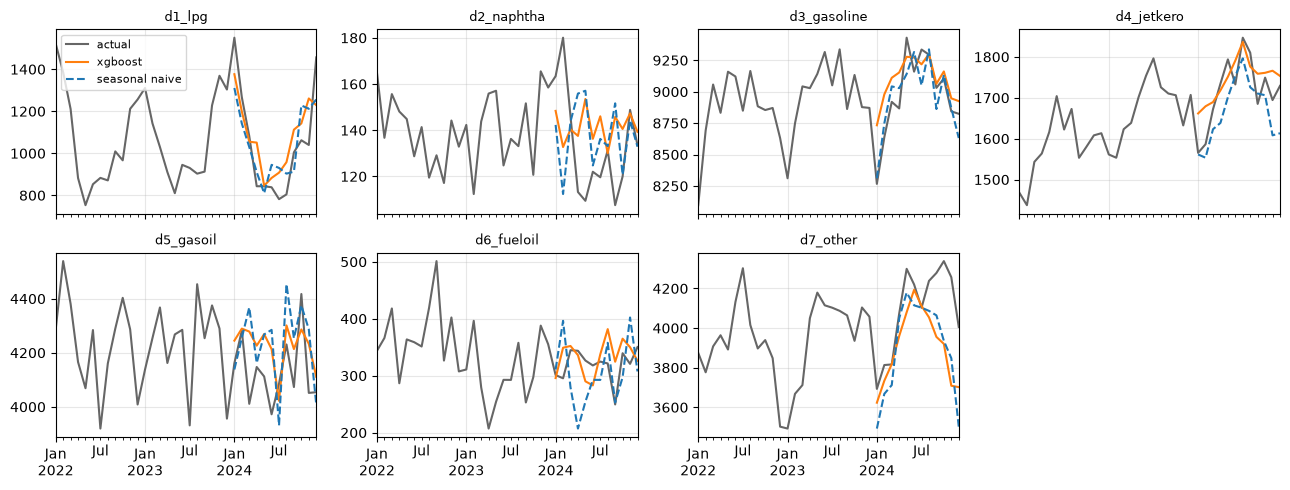

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharex=True)
for ax, product in zip(axes.flat, c.PRODUCTS):
    us[product].loc["2022":"2024"].plot(ax=ax, color="0.4", label="actual")
    path_us[product].plot(ax=ax, color="C1", label="xgboost")
    naive_us[product].plot(ax=ax, color="C0", ls="--", label="seasonal naive")
    ax.set_title(product, fontsize=9); ax.set_xlabel("")
axes.flat[0].legend(fontsize=8); axes.flat[-1].axis("off"); plt.tight_layout();

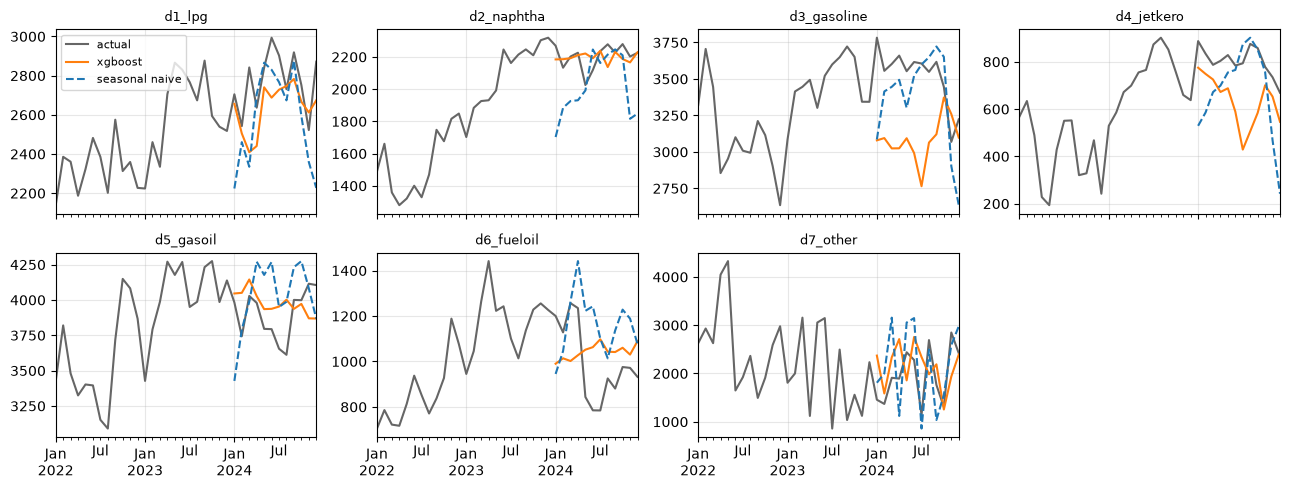

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharex=True)
for ax, product in zip(axes.flat, c.PRODUCTS):
    china[product].loc["2022":"2024"].plot(ax=ax, color="0.4", label="actual")
    path_china[product].plot(ax=ax, color="C1", label="xgboost")
    naive_china[product].plot(ax=ax, color="C0", ls="--", label="seasonal naive")
    ax.set_title(product, fontsize=9); ax.set_xlabel("")
axes.flat[0].legend(fontsize=8); axes.flat[-1].axis("off"); plt.tight_layout();

## Evaluation

In [32]:
model.score(us, path_us).round(2)

d1_lpg        11.64
d2_naphtha    16.16
d3_gasoline    1.87
d4_jetkero     2.74
d5_gasoil      3.01
d6_fueloil    10.24
d7_other       4.56
weighted       3.44
dtype: float64

In [33]:
results = pd.DataFrame({("us", "xgboost"): model.score(us, path_us),
                        ("us", "seasonal naive"): model.score(us, naive_us),
                        ("china", "xgboost"): model.score(china, path_china),
                        ("china", "seasonal naive"): model.score(china, naive_china)}).round(2)
results

us                  china               
            xgboost seasonal naive xgboost seasonal naive
d1_lpg        11.64          11.76    5.38           7.55
d2_naphtha    16.16          16.33    2.73           9.55
d3_gasoline    1.87           1.50   13.17           6.37
d4_jetkero     2.74           3.36   20.72          18.81
d5_gasoil      3.01           3.62    4.52           7.00
d6_fueloil    10.24          16.56   18.93          24.31
d7_other       4.56           4.82   31.83          30.38
weighted       3.44           3.61   11.32          11.79

## Drivers

In [34]:
%%time
# lags only, then one driver dropped at a time, same hyperparameters
runs = {}
for region, df, path, chosen in [("us", us, path_us, chosen_us), ("china", china, path_china, chosen_china)]:
    runs[(region, "all drivers")] = model.score(df, path)["weighted"]
    runs[(region, "lags only")] = model.score(df, model.forecast(df[c.PRODUCTS], chosen=chosen)[0])["weighted"]
    for driver in df.columns.drop(c.PRODUCTS):
        stripped = model.forecast(df.drop(columns=driver), chosen=chosen)[0]
        runs[(region, "without " + driver)] = model.score(df, stripped)["weighted"]
ablation = pd.Series(runs).unstack(0).round(2)
ablation

CPU times: user 2min 56s, sys: 1min 35s, total: 4min 32s
Wall time: 2min 51s


,china,us
all drivers,11.32,3.44
lags only,13.68,3.29
without inc,NaN,3.29
without ind,NaN,3.56
without inv,10.96,NaN
without lkq_credit,11.67,NaN
without lkq_electricity,10.83,NaN
without rpk,NaN,3.42
without rpo_real,NaN,3.33
without vmt,NaN,3.46


In [35]:
(ablation - ablation.loc["all drivers"]).round(2)  # change in weighted MAPE: negative means the driver hurts

,china,us
all drivers,0.00,0.00
lags only,2.36,-0.15
without inc,NaN,-0.15
without ind,NaN,0.12
without inv,-0.36,NaN
without lkq_credit,0.35,NaN
without lkq_electricity,-0.49,NaN
without rpk,NaN,-0.02
without rpo_real,NaN,-0.11
without vmt,NaN,0.02


In [36]:
# how much the score moves for no reason: same features, other seeds
seeds = {}
for seed in (1, 2, 3):
    model.PARAMS["random_state"] = seed
    seeds[("us", seed)] = model.score(us, model.forecast(us, chosen=chosen_us)[0])["weighted"]
    seeds[("china", seed)] = model.score(china, model.forecast(china, chosen=chosen_china)[0])["weighted"]
model.PARAMS["random_state"] = 42
pd.Series(seeds).unstack(0).round(2)

,china,us
1,11.22,3.47
2,11.01,3.60
3,10.89,3.53
